In [1]:
import arc
from arc import *
import matplotlib.pyplot as plt
import numpy as np
from IPython.display import Latex
import scipy
%pip install -q matplotlib numpy pairinteraction

import pairinteraction as pi
from pairinteraction.visualization.colormaps import alphamagma


if pi.Database.get_global_database() is None:
    pi.Database.initialize_global_database(download_missing=True)
from scipy.constants import h, hbar

Note: you may need to restart the kernel to use updated packages.


In [2]:
single_channel_c3s = []
fitted_c3 = []

In [4]:
Rb = arc.Rubidium()
Cs = arc.Caesium()

cs_dif = 3

min_n = 40
max_n = 130
ns = np.arange(min_n,max_n)

Rb_decay = False

jps = [(1/2,1/2), (1/2,3/2), (3/2,1/2), (3/2,3/2)]
Dkls = [4/9, 14/9, 14/9, 22/9]

jp_deltas = []
for jp in jps:    
    delta = []
    for n in ns:
        nb = n+cs_dif
        if Rb_decay:
            defect_Rb = Rb.getEnergy(n-1, 1, jp[0], 1/2) - Rb.getEnergy(n, 0, 1/2, 1/2)
            defect_Cs = Cs.getEnergy(nb, 0, 1/2, 1/2) - Cs.getEnergy(nb, 1, jp[1], 1/2)
            defect = defect_Rb - defect_Cs
            delta.append(defect*1.6e-19/h/1e9)
        else:
            defect_Rb = Rb.getEnergy(n, 1, jp[0], 1/2) - Rb.getEnergy(n, 0, 1/2, 1/2)
            defect_Cs = Cs.getEnergy(nb, 0, 1/2, 1/2) - Cs.getEnergy(nb-1, 1, jp[1], 1/2)
            defect = defect_Rb - defect_Cs
            delta.append(defect*1.6e-19/h/1e9)
    
    jp_deltas.append(delta)



In [5]:
min_defects = [min(np.array(jp_deltas[0]), key=abs), 
               min(np.array(jp_deltas[1]), key=abs), 
               min(np.array(jp_deltas[2]), key=abs), 
               min(np.array(jp_deltas[3]), key=abs)]
assoc_ns = [ns[jp_deltas[0].index(min_defects[0])],
            ns[jp_deltas[1].index(min_defects[1])],
            ns[jp_deltas[2].index(min_defects[2])],
            ns[jp_deltas[3].index(min_defects[3])]]
print(list(ns))



[np.int64(40), np.int64(41), np.int64(42), np.int64(43), np.int64(44), np.int64(45), np.int64(46), np.int64(47), np.int64(48), np.int64(49), np.int64(50), np.int64(51), np.int64(52), np.int64(53), np.int64(54), np.int64(55), np.int64(56), np.int64(57), np.int64(58), np.int64(59), np.int64(60), np.int64(61), np.int64(62), np.int64(63), np.int64(64), np.int64(65), np.int64(66), np.int64(67), np.int64(68), np.int64(69), np.int64(70), np.int64(71), np.int64(72), np.int64(73), np.int64(74), np.int64(75), np.int64(76), np.int64(77), np.int64(78), np.int64(79), np.int64(80), np.int64(81), np.int64(82), np.int64(83), np.int64(84), np.int64(85), np.int64(86), np.int64(87), np.int64(88), np.int64(89), np.int64(90), np.int64(91), np.int64(92), np.int64(93), np.int64(94), np.int64(95), np.int64(96), np.int64(97), np.int64(98), np.int64(99), np.int64(100), np.int64(101), np.int64(102), np.int64(103), np.int64(104), np.int64(105), np.int64(106), np.int64(107), np.int64(108), np.int64(109), np.int64(

In [6]:
print((Rb.getEnergy(assoc_ns[0], 1, 1/2) - Rb.getEnergy(assoc_ns[0], 0, 1/2))*1.6e-19/h/1e9 * 0.0005)

print(min_defects[0])

0.0007802575931298485
-0.15125703114304134


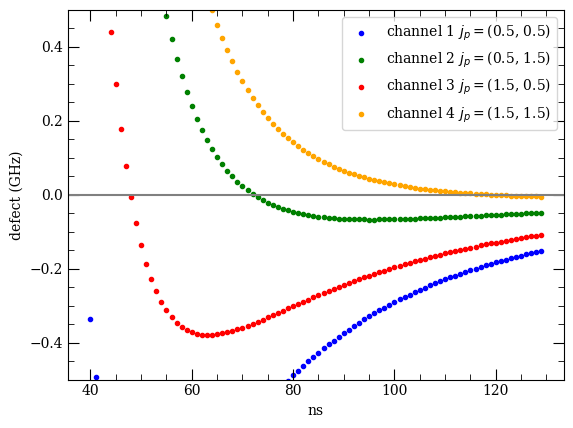

1
channel 2 = |Rb 71s_1/2, Cs 74s_1/2> -> |Rb 71p_0.5, Cs 73p_1.5>
j_pa, j_pb = (0.5, 1.5)
min defect = 12.457281040642219
n = 71
2
channel 2 = |Rb 72s_1/2, Cs 75s_1/2> -> |Rb 72p_0.5, Cs 74p_1.5>
j_pa, j_pb = (0.5, 1.5)
min defect = 2.575149424746158
n = 72
3
channel 2 = |Rb 73s_1/2, Cs 76s_1/2> -> |Rb 73p_0.5, Cs 75p_1.5>
j_pa, j_pb = (0.5, 1.5)
min defect = -6.244462228362467
n = 73
4
channel 3 = |Rb 48s_1/2, Cs 51s_1/2> -> |Rb 48p_1.5, Cs 50p_0.5>
j_pa, j_pb = (1.5, 0.5)
min defect = -5.82021042976261
n = 48
5
channel 4 = |Rb 118s_1/2, Cs 121s_1/2> -> |Rb 118p_1.5, Cs 120p_1.5>
j_pa, j_pb = (1.5, 1.5)
min defect = 0.9712609892995178
n = 118
6
channel 4 = |Rb 119s_1/2, Cs 122s_1/2> -> |Rb 119p_1.5, Cs 121p_1.5>
j_pa, j_pb = (1.5, 1.5)
min defect = 0.22815492140972926
n = 119
7
channel 4 = |Rb 120s_1/2, Cs 123s_1/2> -> |Rb 120p_1.5, Cs 122p_1.5>
j_pa, j_pb = (1.5, 1.5)
min defect = -0.4660008532927875
n = 120


In [7]:

plt.figure()
plt.scatter(ns,jp_deltas[0], label=f'channel {1} $j_p =$' + str(jps[0]), color = 'blue', marker='.')
plt.scatter(ns,jp_deltas[1], label=f'channel {2} $j_p =$' + str(jps[1]), color = 'green', marker='.')
plt.scatter(ns,jp_deltas[2], label=f'channel {3} $j_p =$' + str(jps[2]), color = 'red', marker='.')
plt.scatter(ns,jp_deltas[3], label=f'channel {4} $j_p =$' + str(jps[3]), color = 'orange', marker='.')

plt.axhline(y=0, color='grey')
plt.legend()
plt.ylabel('defect (GHz)')
plt.xlabel('ns')

plt.ylim([-0.5,0.5])

plt.show()

relevant_channel = []
w = 1
for i in range(4):
    
    if Rb_decay:
        for j in range(3):
            if assoc_ns[i] + (j-1) < max_n-1:
                defect = jp_deltas[i][jp_deltas[i].index(min_defects[i])+(j-1)]*1e3
            else:
                defect = 31
            if abs(defect) < 30:
                print(w)
                w+=1
                print(f'channel {i+1} = |Rb {assoc_ns[i]+(j-1)}s_1/2, Cs {assoc_ns[i]+(j-1)+cs_dif}s_1/2> -> |Rb {assoc_ns[i]+(j-1)-1}p_{jps[i][0]}, Cs {assoc_ns[i]+cs_dif+(j-1)}p_{str(jps[i][1])}>')
                print(f'j_pa, j_pb = {jps[i]}')
                print(f'min defect = {defect}')
                print(f'n = {assoc_ns[i]+(j-1)}')
                
                
                relevant_channel.append([assoc_ns[i]+(j-1), assoc_ns[i]+(j-1)+cs_dif, assoc_ns[i]+(j-1)-1, assoc_ns[i]+cs_dif+(j-1), jps[i][0], jps[i][1], i+1, defect])

        # print(f'channel {i+1} = |Rb {assoc_ns[i]}s_1/2, Cs {assoc_ns[i]+cs_dif}s_1/2> -> |Rb {assoc_ns[i]-1}p_{jps[i][0]}, Cs {assoc_ns[i]+cs_dif}p_{str(jps[i][1])}>')
        # print(f'j_pa, j_pb = {jps[i]}')
        # print(f'min defect = {min_defects[i]*1e3}')
        # if assoc_ns[i] != max_n:
        #     print(f'channel {i+1} = |Rb {assoc_ns[i]+1}s_1/2, Cs {assoc_ns[i]+cs_dif+1}s_1/2> -> |Rb {assoc_ns[i]}p_{jps[i][0]}, Cs {assoc_ns[i]+cs_dif+1}p_{str(jps[i][1])}>')
        #     print(f'j_pa, j_pb = {jps[i]}')
        #     print(f'min defect = {min_defects[i+1]*1e3}')
        #     print(f'n = {assoc_ns[i+1]}')
    
    else:
        for j in range(3):
            if assoc_ns[i] + (j-1) < max_n-1:
                # defect in MHz
                defect = jp_deltas[i][jp_deltas[i].index(min_defects[i])+(j-1)]*1e3
            else:
                defect = 31
            if abs(defect) < 30:
                print(w)
                w+=1
                print(f'channel {i+1} = |Rb {assoc_ns[i]+(j-1)}s_1/2, Cs {assoc_ns[i]+(j-1)+cs_dif}s_1/2> -> |Rb {assoc_ns[i]+(j-1)}p_{jps[i][0]}, Cs {assoc_ns[i]+cs_dif-1+(j-1)}p_{str(jps[i][1])}>')
                print(f'j_pa, j_pb = {jps[i]}')
                print(f'min defect = {defect}')
                print(f'n = {assoc_ns[i]+(j-1)}')
                
                relevant_channel.append([assoc_ns[i]+(j-1), assoc_ns[i]+(j-1)+cs_dif, assoc_ns[i]+(j-1), assoc_ns[i]+cs_dif+(j-1)-1, jps[i][0], jps[i][1], i+1, defect, Dkls[i]])

            
           
           
            # if assoc_ns[i] != max_n-1:
            #     print(f'channel {i+1} = |Rb {assoc_ns[i]+1}s_1/2, Cs {assoc_ns[i]+cs_dif+1}s_1/2> -> |Rb {assoc_ns[i]}p_{jps[i][0]}, Cs {assoc_ns[i]+cs_dif+1}p_{str(jps[i][1])}>')
            #     print(f'j_pa, j_pb = {jps[i]}')
            #     print(f'min defect = {jp_deltas[i][assoc_ns[i]+1]*1e3}')
            #     print(f'n = {assoc_ns[i]+1}')
            # print(f'channel {i+1} = |Rb {assoc_ns[i]-1}s_1/2, Cs {assoc_ns[i]+cs_dif-1}s_1/2> -> |Rb {assoc_ns[i]-2}p_{jps[i][0]}, Cs {assoc_ns[i]+cs_dif-1}p_{str(jps[i][1])}>')
            # print(f'j_pa, j_pb = {jps[i]}')
            # print(f'n = {assoc_ns[i]-1}')
            # print(f'min defect = {jp_deltas[i][assoc_ns[i]-min_n-1]*1e3}')
        



In [8]:
epsilon_0 = scipy.constants.epsilon_0
a_0 = scipy.constants.physical_constants['Bohr radius']
e = scipy.constants.e

# C3k coefficients
c3ks = []
w=1
for c in relevant_channel:
    rb_matrix_element_j = arc.Rubidium().getReducedMatrixElementJ(c[0], 0, .5, c[2], 1, c[4])

    cs_matrix_element_j = arc.Caesium().getReducedMatrixElementJ(c[1], 0, .5, c[3], 1, c[5])

    c3k = (a_0[0]*e) **2 / h / (4*np.pi*epsilon_0) * cs_matrix_element_j * rb_matrix_element_j/np.sqrt(2*c[4]+1)/np.sqrt(2*c[5]+1)
    c3ks.append(c3k*1e9)

    print(w)
    w+=1
    print(f'channel {c[6]} = |Rb {c[0]}s_1/2, Cs {c[1]}s_1/2> -> |Rb {c[2]}p_{c[4]}, Cs {c[3]}p_{c[5]}>')
    print(f'c3k = {c3k*1e9}')
    print(f'c3 = {c3k*1e9*np.sqrt(c[8])}')
    print(f'Rc = {(c3k*1e9*np.sqrt(c[8])/abs(c[7])*1e3)**(1/3)}')


1
channel 2 = |Rb 71s_1/2, Cs 74s_1/2> -> |Rb 71p_0.5, Cs 73p_1.5>
c3k = 9.107971754281262
c3 = 11.359636597644965
Rc = 9.697215759493464
2
channel 2 = |Rb 72s_1/2, Cs 75s_1/2> -> |Rb 72p_0.5, Cs 74p_1.5>
c3k = 9.648516855978997
c3 = 12.033814788528899
Rc = 16.718614975634555
3
channel 2 = |Rb 73s_1/2, Cs 76s_1/2> -> |Rb 73p_0.5, Cs 75p_1.5>
c3k = 10.212771218990362
c3 = 12.737563623655864
Rc = 12.682273296472266
4
channel 3 = |Rb 48s_1/2, Cs 51s_1/2> -> |Rb 48p_1.5, Cs 50p_0.5>
c3k = 1.6855840982807204
c3 = 2.1022927307869166
Rc = 7.121719001689742
5
channel 4 = |Rb 118s_1/2, Cs 121s_1/2> -> |Rb 118p_1.5, Cs 120p_1.5>
c3k = 71.79450765380125
c3 = 112.24869672271774
Rc = 48.709662511724304
6
channel 4 = |Rb 119s_1/2, Cs 122s_1/2> -> |Rb 119p_1.5, Cs 121p_1.5>
c3k = 74.30473584413411
c3 = 116.17336801094785
Rc = 79.85318562859752
7
channel 4 = |Rb 120s_1/2, Cs 123s_1/2> -> |Rb 120p_1.5, Cs 122p_1.5>
c3k = 76.88022008143528
c3 = 120.20006529621926
Rc = 63.65599787484315


This is more in agreemant with literature

In [9]:
print(len(relevant_channel))

7


0.4982912416256888
14
1.6361474325378431


Diagonalizing interaction matrix...

99% Now we are plotting...


[[71, 1, 0.5, 74, 2, 1.5, np.float64(-0.22510502326722276)],
 [71, 1, 0.5, 74, 2, 2.5, np.float64(-0.06076448451647576)],
 [71, 1, 1.5, 74, 2, 1.5, np.float64(0.047079201489332874)],
 [71, 1, 1.5, 74, 2, 2.5, np.float64(0.21141974024007984)],
 [72, 3, 2.5, 72, 0, 0.5, np.float64(-0.25187859256756945)],
 [72, 3, 3.5, 72, 0, 0.5, np.float64(-0.2523073730019323)],
 [72, 1, 0.5, 74, 1, 1.5, np.float64(0.002578652648366773)],
 [72, 1, 1.5, 74, 1, 0.5, np.float64(-0.34939334932535315)],
 [72, 1, 1.5, 74, 1, 1.5, np.float64(0.26315830870268087)],
 [72, 0, 0.5, 75, 0, 0.5, np.float64(-1.0486356757260187e-13)],
 [73, 1, 0.5, 73, 1, 1.5, np.float64(0.0817802789047956)],
 [73, 1, 1.5, 73, 1, 0.5, np.float64(-0.30799752865462243)],
 [73, 1, 1.5, 73, 1, 1.5, np.float64(0.33140577521085585)],
 [74, 0, 0.5, 73, 0, 0.5, np.float64(0.13520783092944202)]]

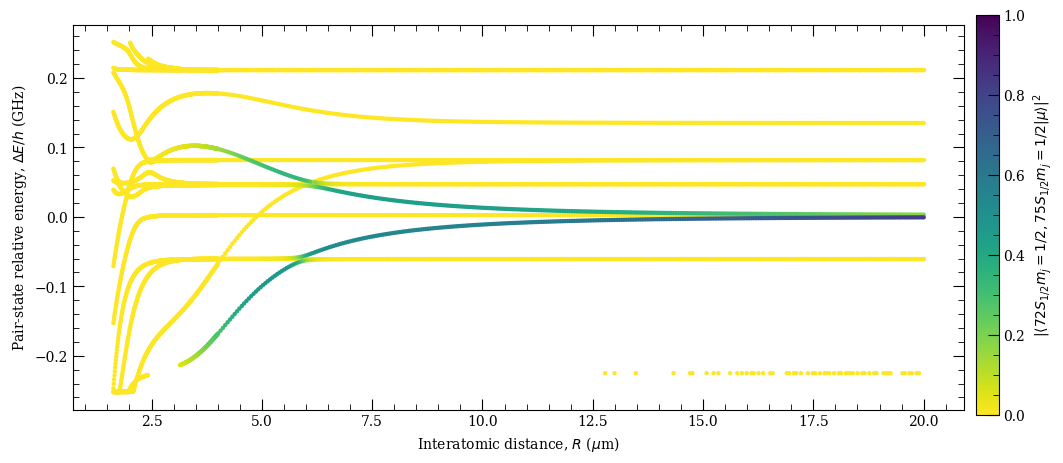

In [11]:
channel = 2
energy_delta = 4e1 * abs(c[7]*1e6)
c = relevant_channel[channel-1]
pair = PairStateInteractions(Rubidium(), c[0], 0, 1/2, c[1], 0, 1/2, 1/2, 1/2, interactionsUpTo=2, s2=1/2, atom2=Caesium())

pair.defineBasis(0, 0, 3, 3, energy_delta, progressOutput=False)

print(energy_delta*1e-9)
print(len(pair.channel))

rvdw = pair.getLeRoyRadius()

print(rvdw)
r = np.append(np.linspace(rvdw, 4, 300), np.linspace(4.01, 20, 300))

nEig = len(pair.channel)
pair.diagonalise(r, nEig, progressOutput=True)

pair.plotLevelDiagram()

pair.channel

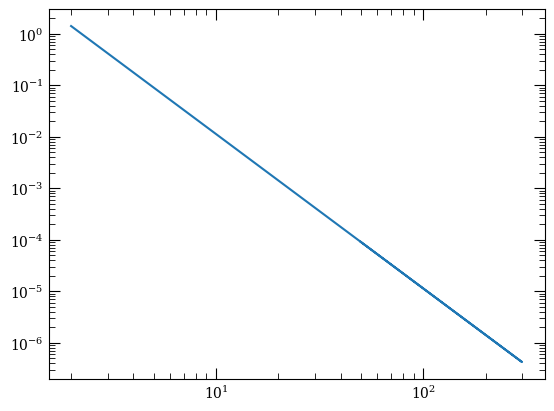

In [10]:

def U(c3, delta, R):
    
    return hbar * delta/2 * (1 - (1 + (2 * c3/hbar/delta/(R**3))**2)**(1/2))

r = np.append(np.linspace(2, 300), np.linspace(4.01, 50, 300))

Us = [abs(U(c3ks[channel-1]*np.sqrt(c[8]), c[7]/1e3, d)) for d in r]
plt.loglog(r, Us)

In [11]:
r = np.linspace(rvdw, 20, 300)

energy_dif = .1

ket1 = pi.KetAtom('Rb', n=c[0], l=0, m=0.5)
basis = pi.BasisAtom('Rb', n=(c[0]-2, c[0]+2), l=(0,1))
system1 = pi.SystemAtom(basis)

ket2 = pi.KetAtom('Cs', n=c[1], l=0, m=0.5)
basis = pi.BasisAtom('Cs', n=(c[1]-2, c[1]+2), l=(0,1))
system2 = pi.SystemAtom(basis)

pair_energy = 1 * (ket1.get_energy(unit = 'GHz') + ket2.get_energy(unit = 'GHz'))
min_energy, max_energy = pair_energy - energy_dif, pair_energy + energy_dif

pair_basis = pi.BasisPair([system1, system2], energy = (min_energy, max_energy), energy_unit="GHz", m=(1, 1)
)


print(pair_basis.number_of_kets)
print(pair_basis.states)
print(pair_basis.kets)



pair_systems = [
    pi.SystemPair(pair_basis).set_distance(d, unit="micrometer") for d in r
]

pi.diagonalize(pair_systems, diagonalizer="eigen", sort_by_energy=True)

eigenenergies = [system.get_eigenenergies(unit="GHz") - pair_energy for system in pair_systems]
overlaps = [system.get_eigenbasis().get_overlaps([ket1, ket2]) for system in pair_systems]

5
[StatePair(1.00 |Rb:71,S_1/2,1/2; Cs:74,S_1/2,1/2⟩), StatePair(1.00 |Rb:71,P_1/2,-1/2; Cs:73,P_3/2,3/2⟩), StatePair(1.00 |Rb:71,P_1/2,1/2; Cs:73,P_3/2,1/2⟩), StatePair(1.00 |Rb:72,P_1/2,-1/2; Cs:72,P_3/2,3/2⟩), StatePair(1.00 |Rb:72,P_1/2,1/2; Cs:72,P_3/2,1/2⟩)]
[KetPair(Rb:71,S_1/2,1/2; Cs:74,S_1/2,1/2), KetPair(Rb:71,P_1/2,-1/2; Cs:73,P_3/2,3/2), KetPair(Rb:71,P_1/2,1/2; Cs:73,P_3/2,1/2), KetPair(Rb:72,P_1/2,-1/2; Cs:72,P_3/2,3/2), KetPair(Rb:72,P_1/2,1/2; Cs:72,P_3/2,1/2)]


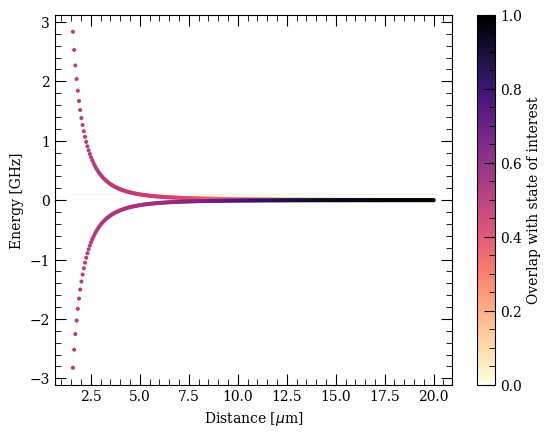

In [12]:
fig, ax = plt.subplots()

ax.set_xlabel(r"Distance [$\mu$m]")
ax.set_ylabel("Energy [GHz]")

try:
    ax.plot(r, np.array(eigenenergies), c="0.9", lw=0.25, zorder=-10)
except ValueError:  # inhomogeneous shape -> no simple line plot possible
    for x, es in zip(r, eigenenergies):
        ax.plot([x] * len(es), es, c="0.9", ls="None", marker=".", zorder=-10)

x_repeated = np.hstack([val * np.ones_like(es) for val, es in zip(r, eigenenergies)])
energies_flattened = np.hstack(eigenenergies)
overlaps_flattened = np.hstack(overlaps)
sorter = np.argsort(overlaps_flattened)

scat = ax.scatter(
    x_repeated[sorter],
    energies_flattened[sorter],
    c=overlaps_flattened[sorter],
    s=15,
    vmin=0,
    vmax=1,
    cmap=alphamagma,
    marker = '.'
)

fig.colorbar(scat, ax=ax, label="Overlap with state of interest", cmap = 'plasma')

plt.show()

Data points to fit =  600
Rvdw =   12.212189565274352  mu m
offset =  1.0000104857828361e-08 
 scale =  -11.353401193836293


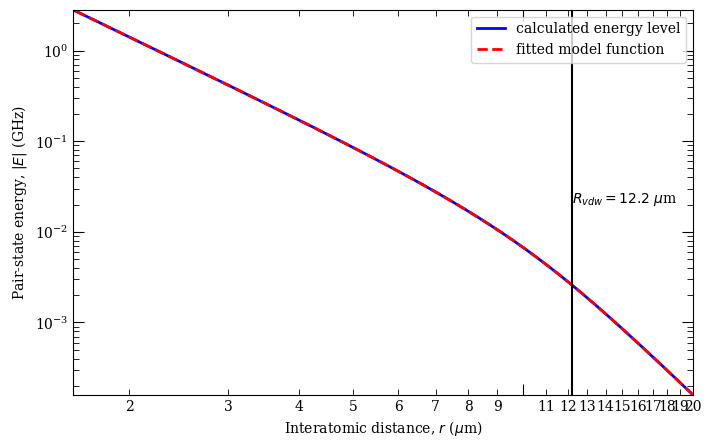

c3 =  11.345017678849777  GHz /R^3 (mu m)^3
offset =  -0.005694232278348393


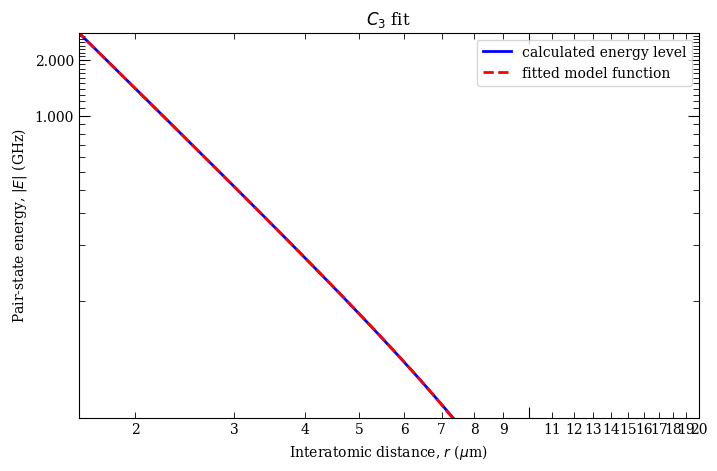

c6 =  9935.057847523416  GHz /R^6 (mu m)^6
offset =  4.726070575508517e-06


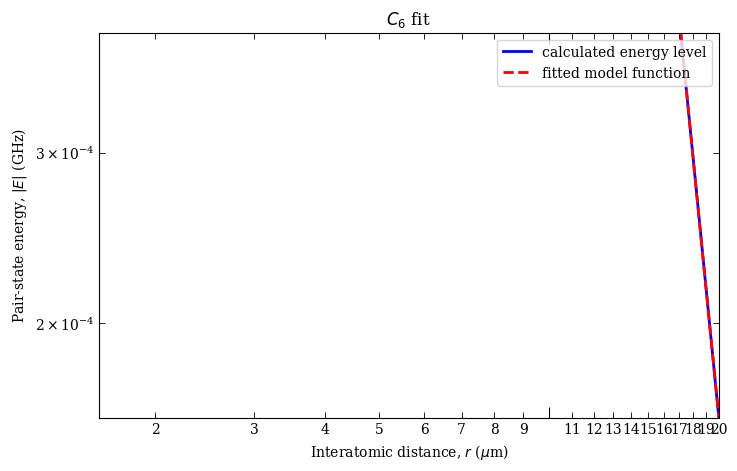

12.212189565274352


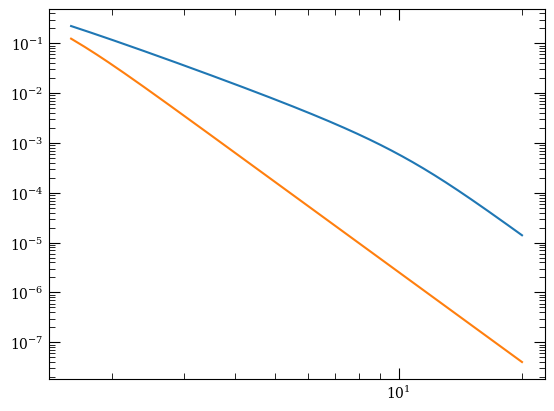

In [13]:
minStateContribution=.0

rvdw2 = pair.getVdwFromLevelDiagram(
    .500000, 30.000000, minStateContribution = minStateContribution, showPlot=True
)
c3 = pair.getC3fromLevelDiagram(
    0, rvdw2 * 0.6, showPlot=True, minStateContribution = minStateContribution
)
c6 = pair.getC6fromLevelDiagram(
    1.4 * rvdw2, rvdw2 + 30.0, showPlot=True, minStateContribution = minStateContribution
)
plt.figure()

print(rvdw2)

A = 1
B = 1
E = [A+B*(1-np.sqrt(1+(rvdw2/rs)**6))/(1-np.sqrt(1+rvdw2**6)) for rs in r]
E2 = [A+B*(1-np.sqrt(1+(rvdw/rs)**6))/(1-np.sqrt(1+rvdw**6)) for rs in r]

plt.loglog(r, np.log(E))
plt.loglog(r, np.log(E2))
plt.yscale('log')
plt.show()

In [14]:
no_states = []
c3_fits = []
rvdws = []

                  ARPACK can only find up to dimension-1 eigenvectors, where                dimension is matrix dimension.

 Now we are plotting...
Data points to fit =  600
Rvdw =   12.212189565274347  mu m
offset =  1.0000104858243005e-08 
 scale =  -11.353401193836298
c3 =  11.330597158008882  GHz /R^3 (mu m)^3
offset =  -0.005397608531559234


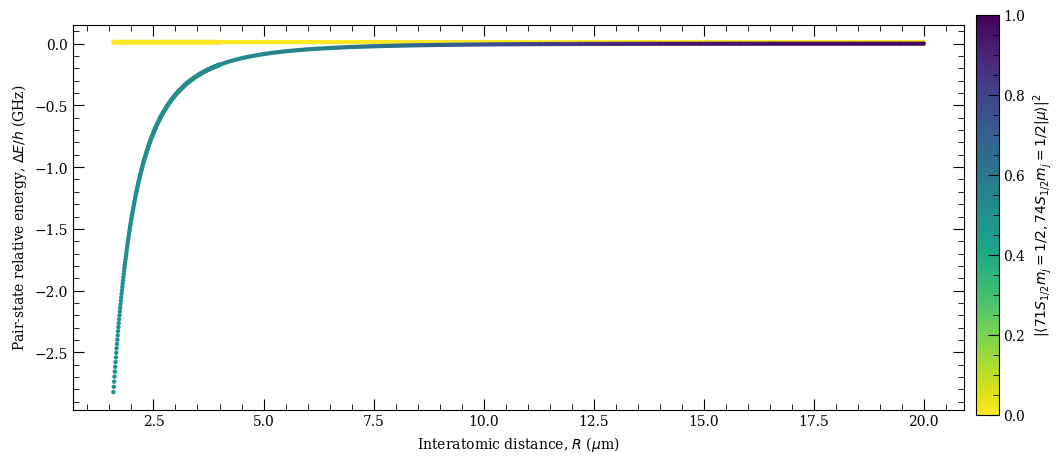

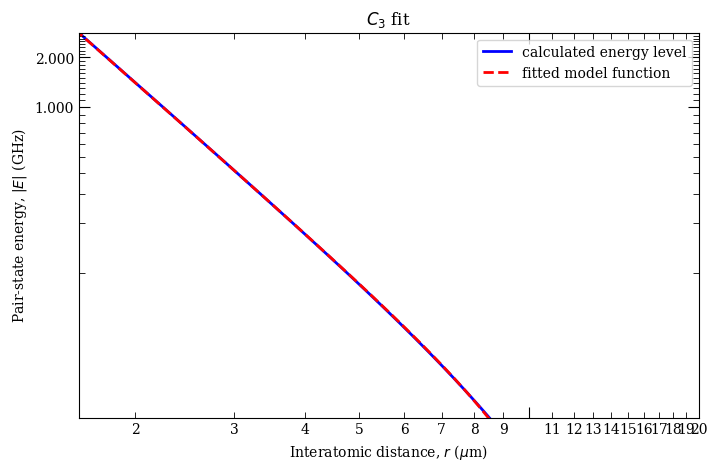

 Now we are plotting...
Data points to fit =  248
Rvdw =   12.202493438109219  mu m
offset =  -2.9419356668145496e-08 
 scale =  -11.38169563771761
c3 =  11.059994417696474  GHz /R^3 (mu m)^3
offset =  -0.004742533808118908


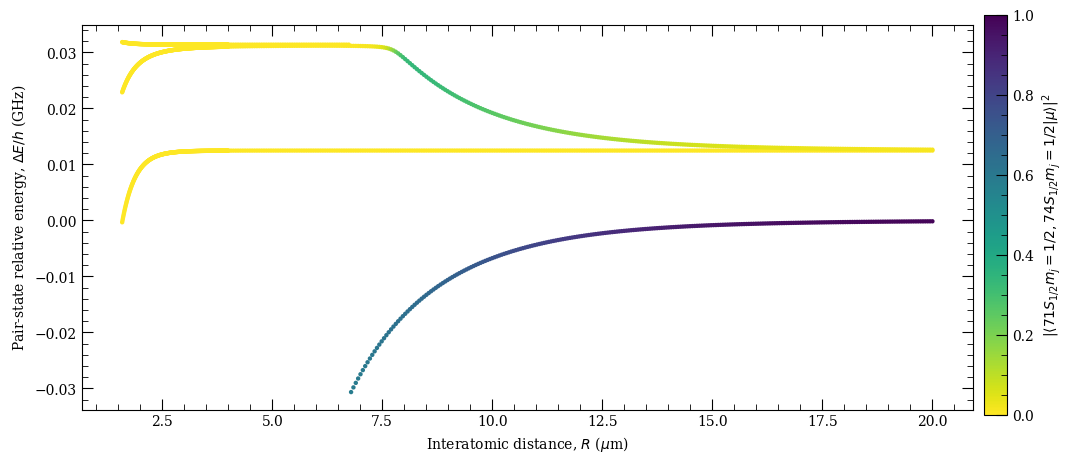

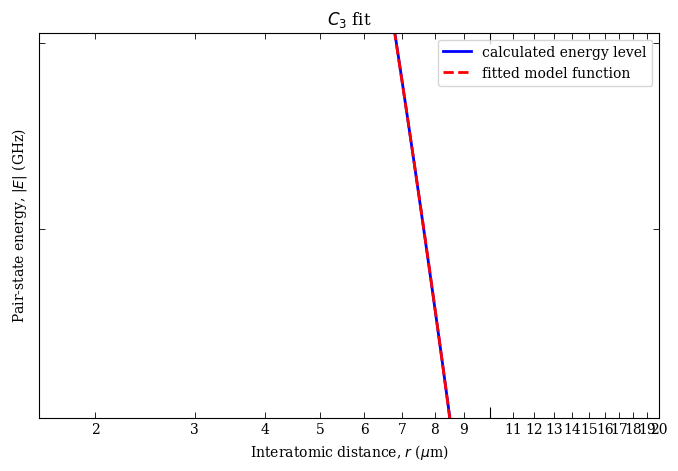

 Now we are plotting...
Data points to fit =  248
Rvdw =   12.209902129195438  mu m
offset =  4.5879454978728726e-08 
 scale =  -11.364054068450429
c3 =  11.025311524221609  GHz /R^3 (mu m)^3
offset =  -0.004692977472830863


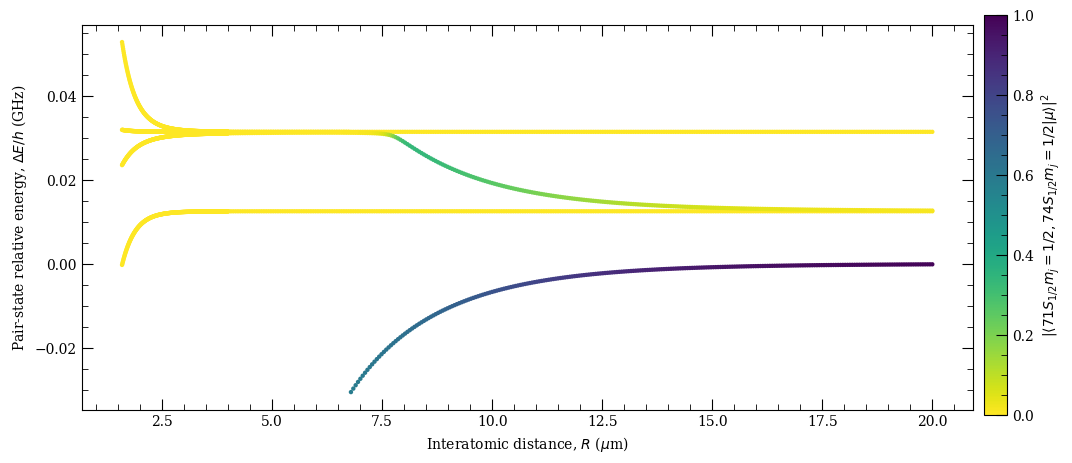

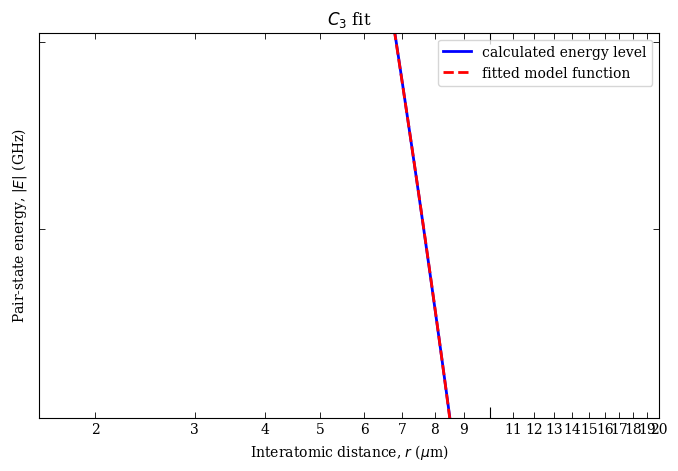

 Now we are plotting...
Data points to fit =  283
Rvdw =   12.289343652829217  mu m
offset =  1.6094888136020799e-06 
 scale =  -11.221749521243584
c3 =  10.835349281679177  GHz /R^3 (mu m)^3
offset =  -0.004256917914330277


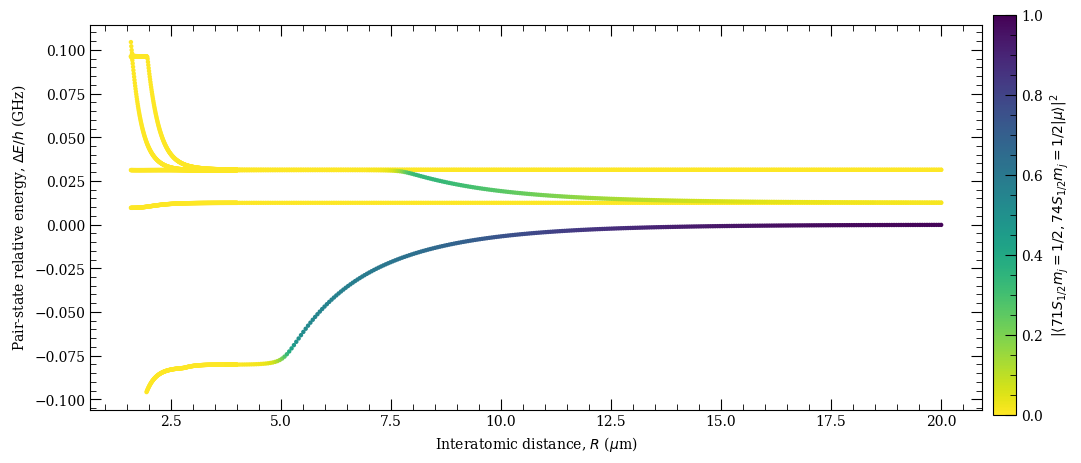

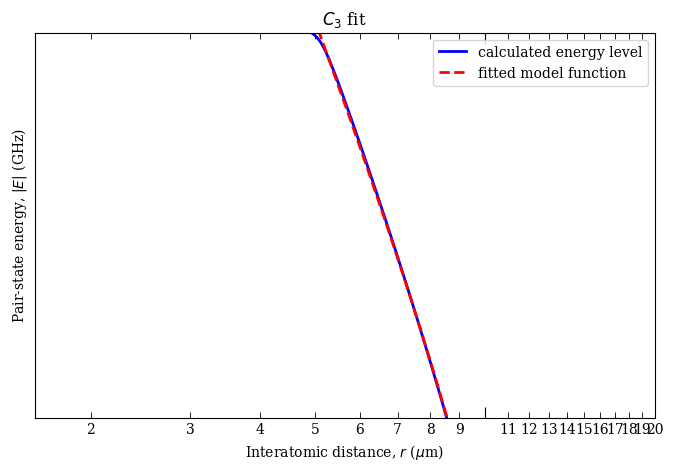

 Now we are plotting...
Data points to fit =  283
Rvdw =   12.288938195161968  mu m
offset =  1.6040669983138074e-06 
 scale =  -11.222583384610477
c3 =  10.836571894770623  GHz /R^3 (mu m)^3
offset =  -0.004258803009333347


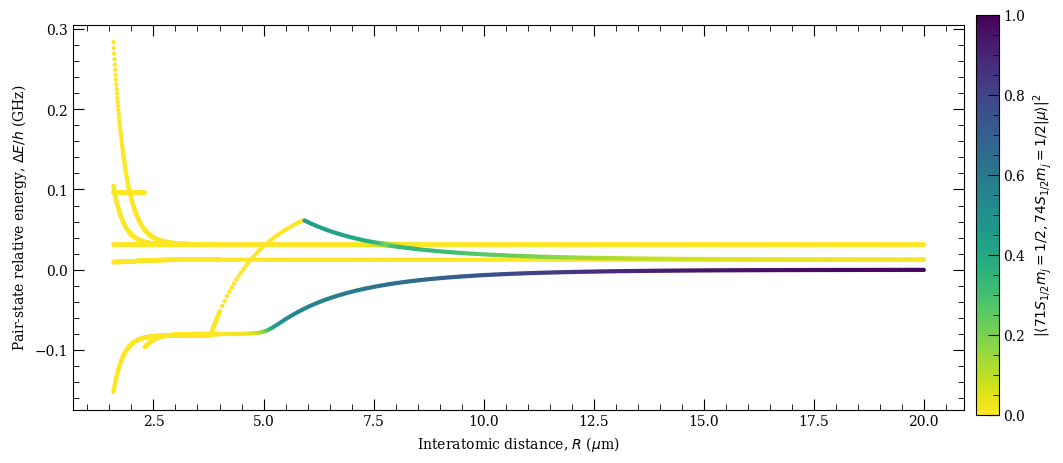

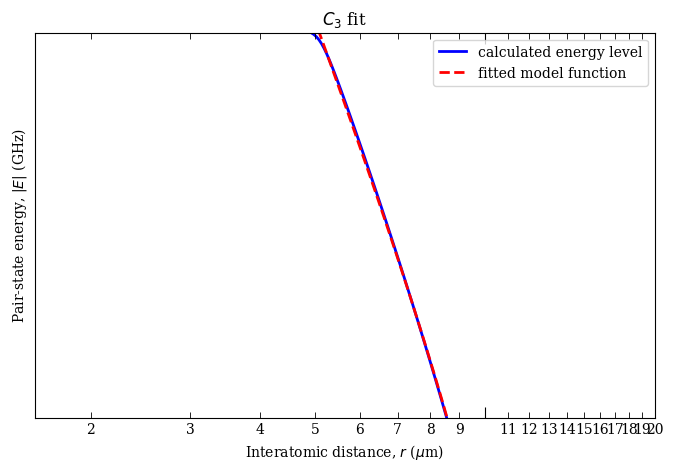

 Now we are plotting...
Data points to fit =  283
Rvdw =   12.288938021642373  mu m
offset =  1.604055735876512e-06 
 scale =  -11.222583525523554
c3 =  10.83657186800137  GHz /R^3 (mu m)^3
offset =  -0.004258802931391365


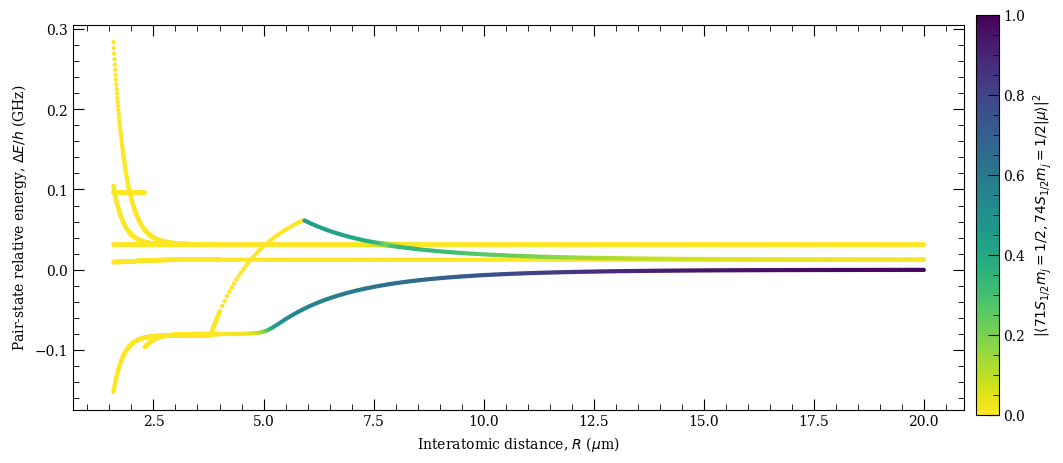

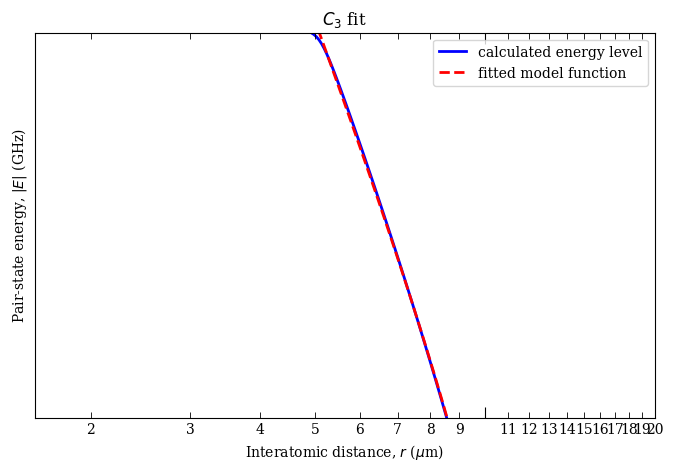

 Now we are plotting...
Data points to fit =  283
Rvdw =   12.283242177091815  mu m
offset =  1.530559997171802e-06 
 scale =  -11.235102062105256
c3 =  10.854982896186973  GHz /R^3 (mu m)^3
offset =  -0.004286873478451752


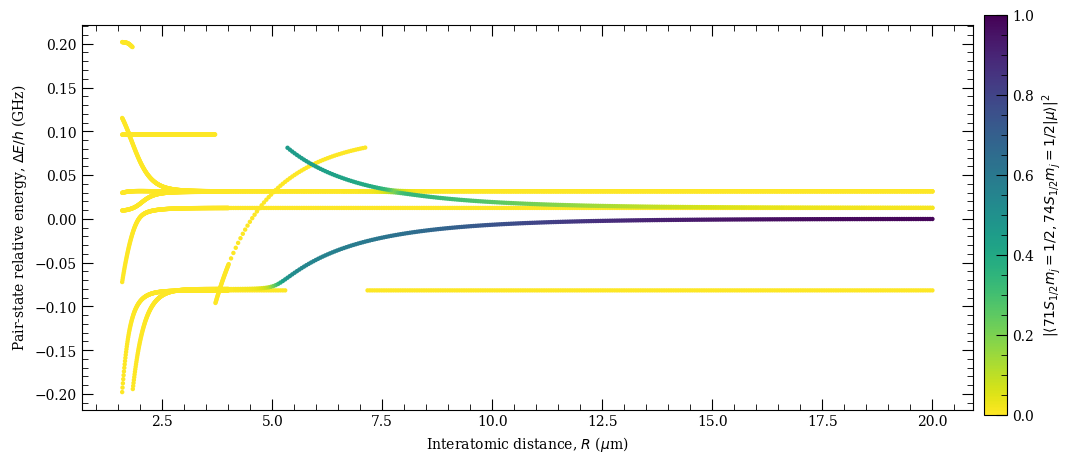

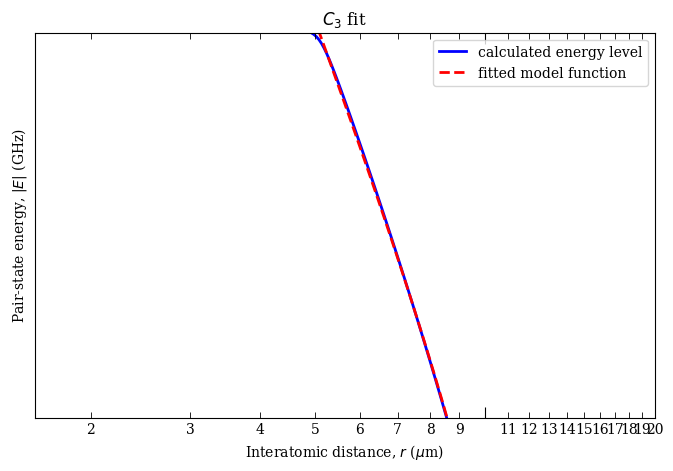

 Now we are plotting...
Data points to fit =  279
Rvdw =   12.239899322905666  mu m
offset =  6.547001591671563e-07 
 scale =  -11.311582121293398
c3 =  11.028131279258059  GHz /R^3 (mu m)^3
offset =  -0.004673982884478309


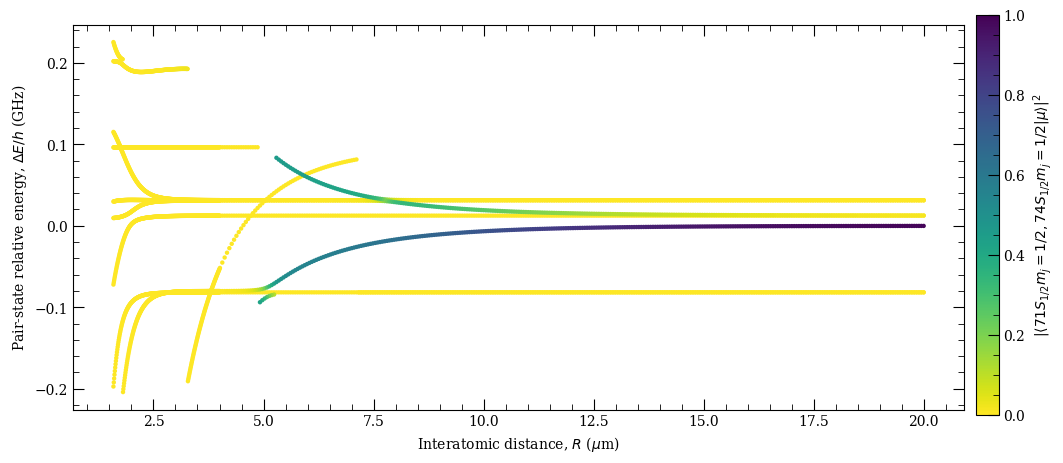

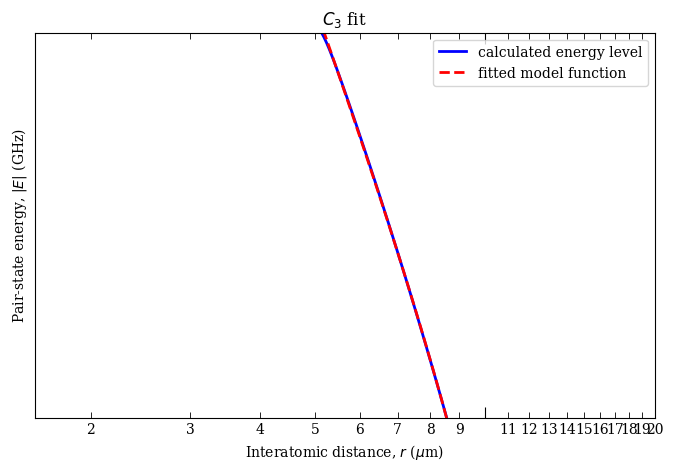

 Now we are plotting...
Data points to fit =  274
Rvdw =   11.882792087441846  mu m
offset =  -5.001726326748047e-06 
 scale =  -12.86837302655103
c3 =  13.101273528380874  GHz /R^3 (mu m)^3
offset =  -0.007254492168043651


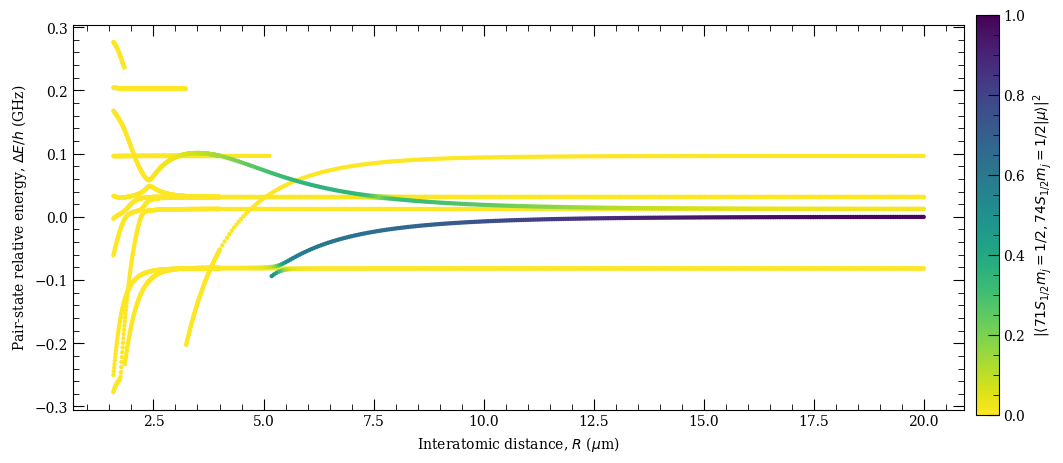

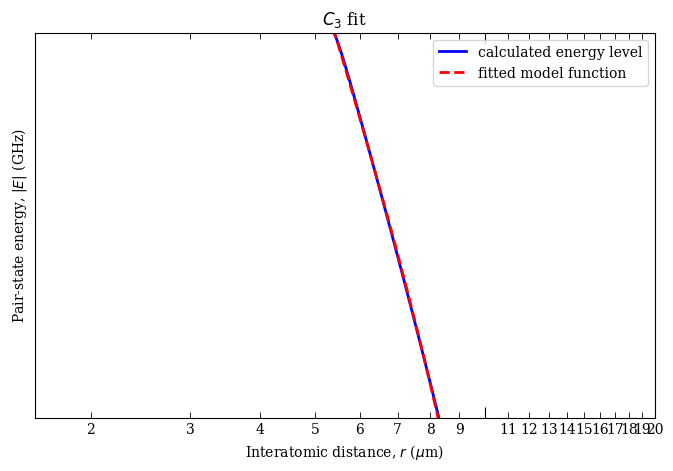

 Now we are plotting...
Data points to fit =  274
Rvdw =   11.882879231420407  mu m
offset =  -5.000285621780958e-06 
 scale =  -12.868012162590132
c3 =  13.10076392600471  GHz /R^3 (mu m)^3
offset =  -0.0072537971751859545


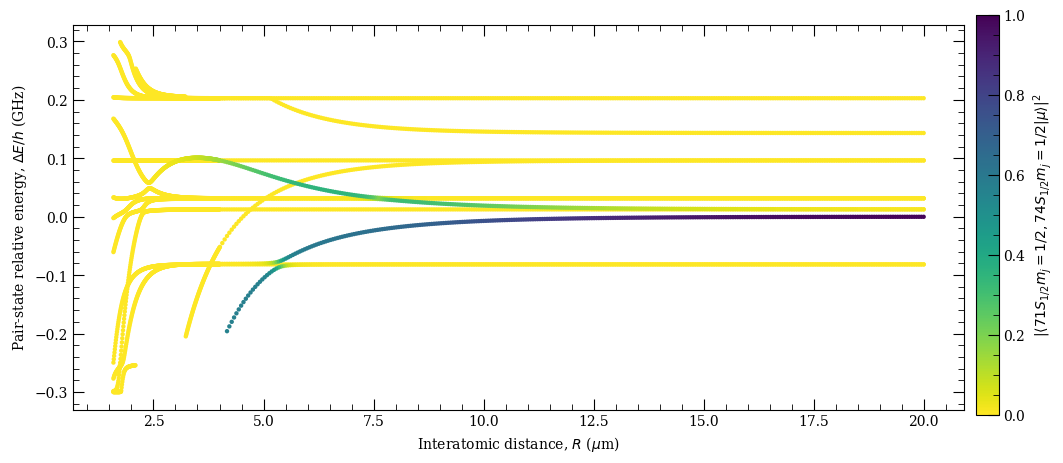

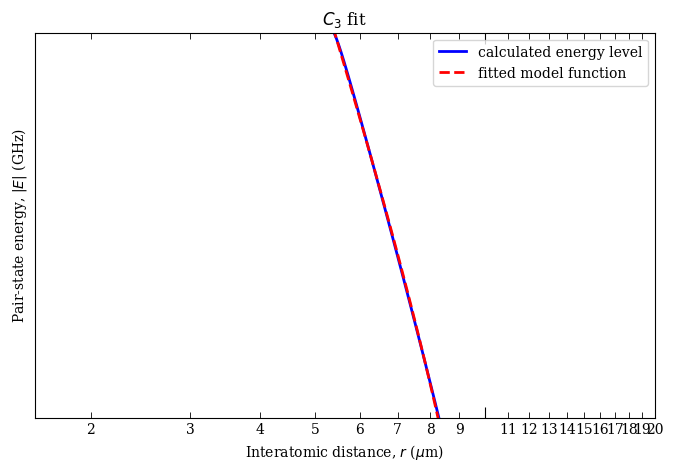

 Now we are plotting...
Data points to fit =  278
Rvdw =   12.160165390953802  mu m
offset =  -4.6989139019035085e-07 
 scale =  -11.883146525275286
c3 =  11.607395762241435  GHz /R^3 (mu m)^3
offset =  -0.0050415903764691366


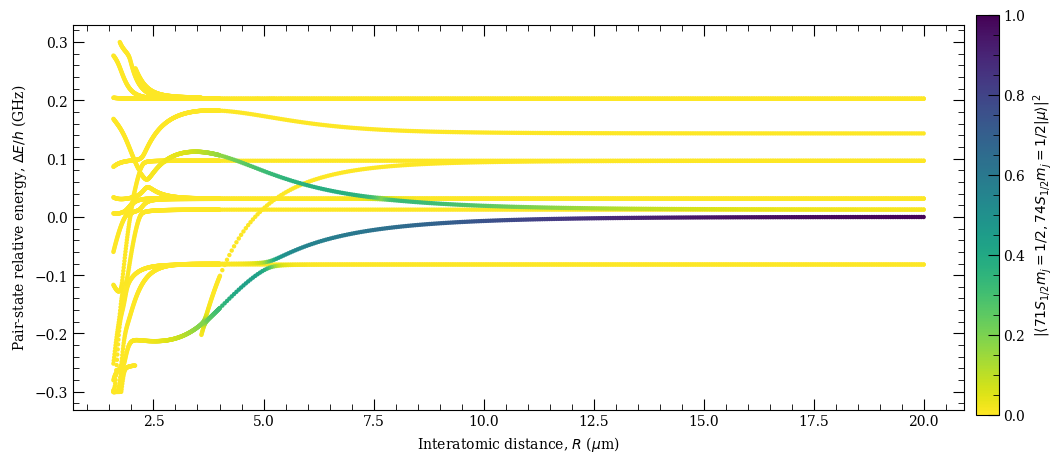

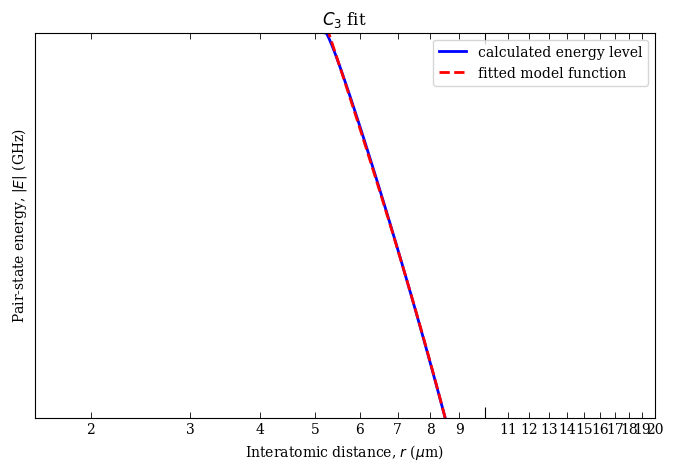

 Now we are plotting...
Data points to fit =  278
Rvdw =   12.149616296836236  mu m
offset =  -6.371565218612211e-07 
 scale =  -11.905556790743246
c3 =  11.647949200972343  GHz /R^3 (mu m)^3
offset =  -0.005113717711474291


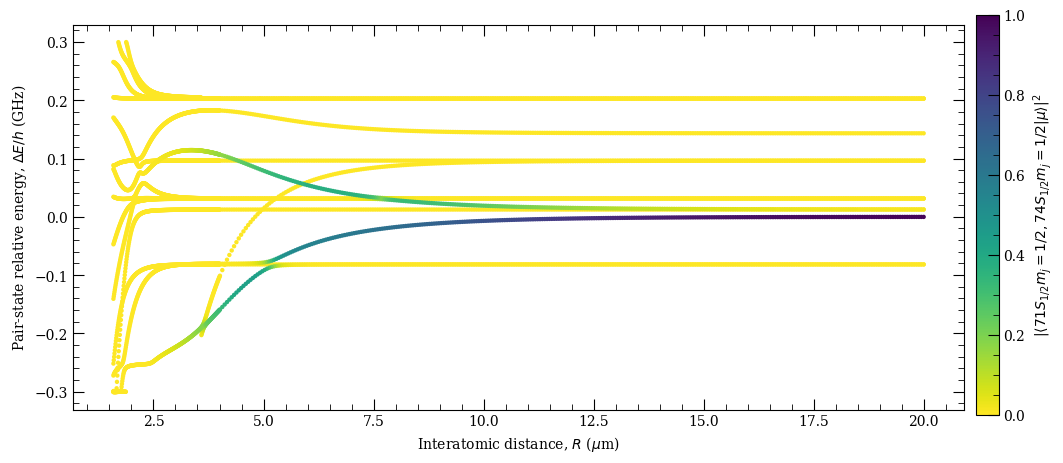

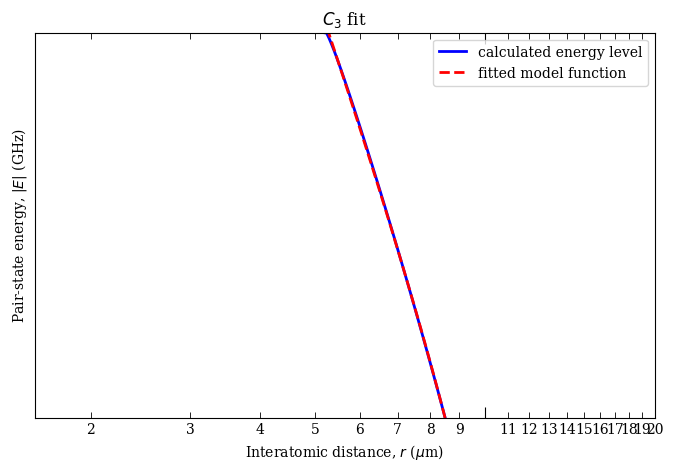

 Now we are plotting...
Data points to fit =  278
Rvdw =   12.149614163737851  mu m
offset =  -6.371981041306698e-07 
 scale =  -11.90556101372755
c3 =  11.647957937680331  GHz /R^3 (mu m)^3
offset =  -0.005113734560395056


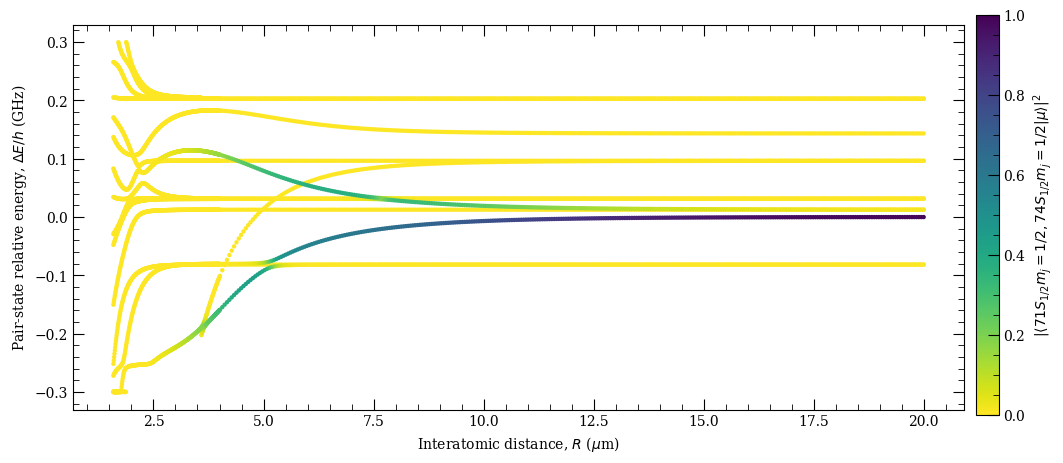

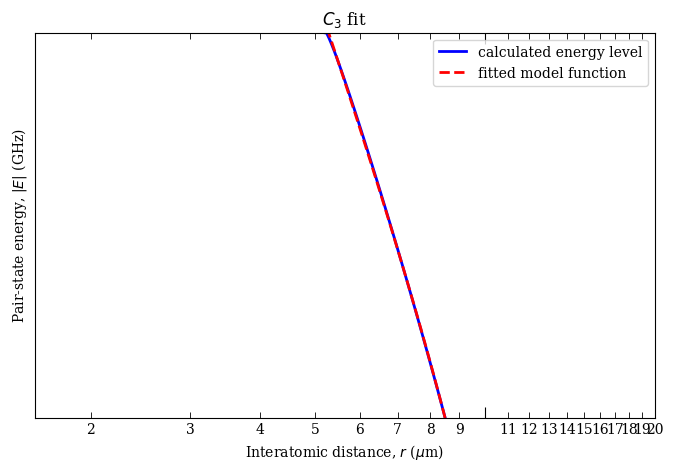

 Now we are plotting...
Data points to fit =  278
Rvdw =   12.14978536056885  mu m
offset =  -6.342089099390212e-07 
 scale =  -11.905210616236582
c3 =  11.647254146783897  GHz /R^3 (mu m)^3
offset =  -0.005112404489955262


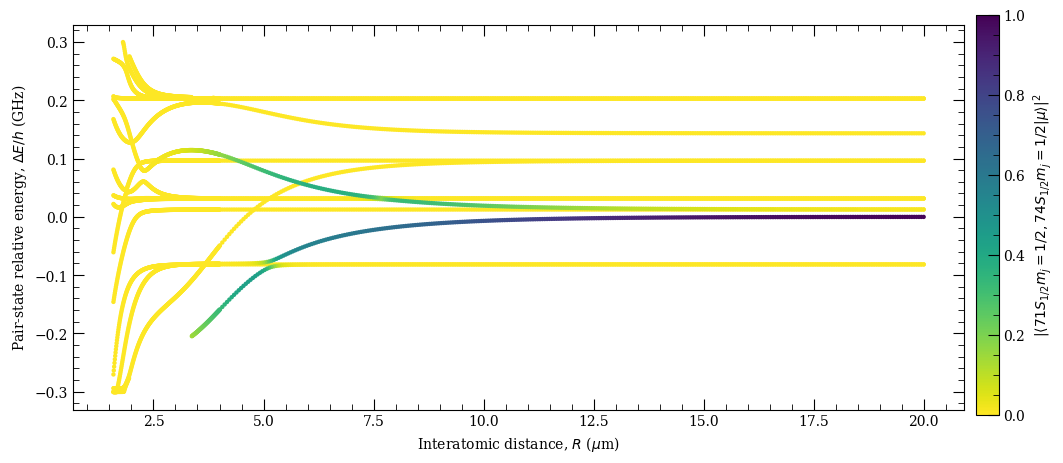

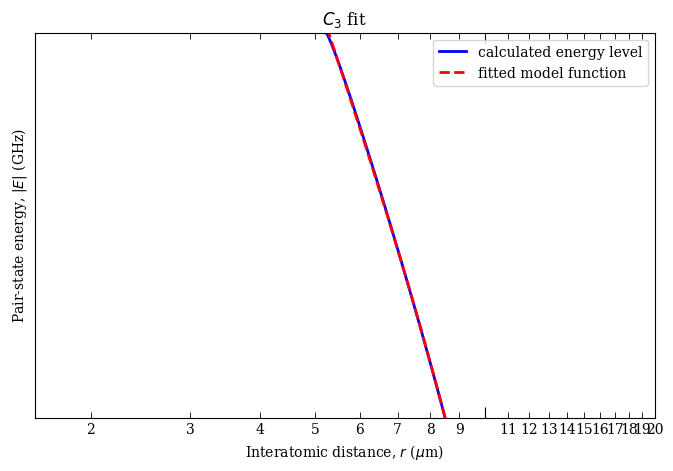

 Now we are plotting...
Data points to fit =  278
Rvdw =   12.149875090906399  mu m
offset =  -6.326888778114219e-07 
 scale =  -11.905024939024276
c3 =  11.64689808845881  GHz /R^3 (mu m)^3
offset =  -0.005111749354504741


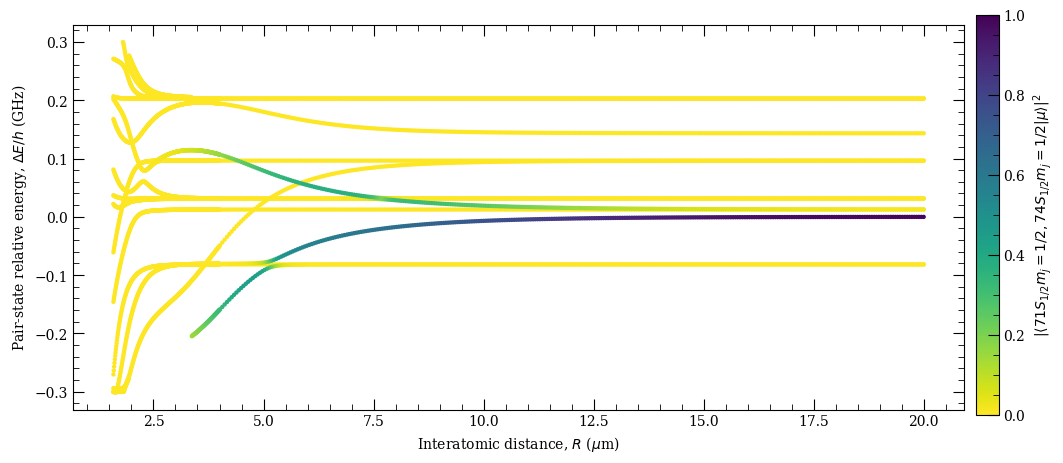

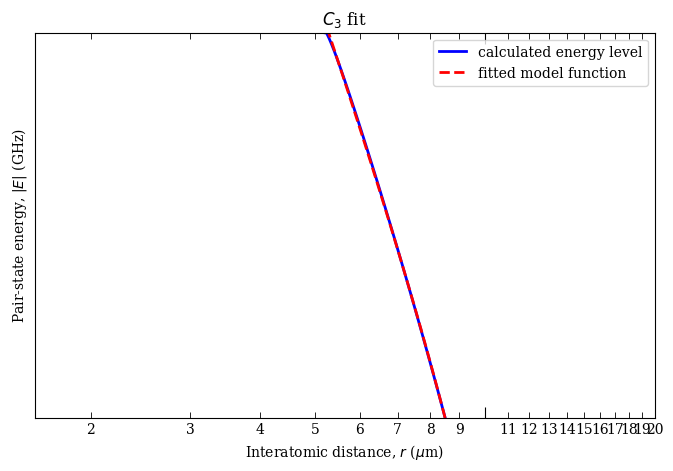

In [15]:

channel = 1
c = relevant_channel[channel-1]

no_states = []
c3_fits=[]
rvdws=[]

energy_deltas = np.linspace(2*abs(c[7]*1e6), 4e1 * abs(c[7]*1e6), 15)
for energy in energy_deltas:    
    
    pair = PairStateInteractions(Rubidium(), c[0], 0, 1/2, c[1], 0, 1/2, 1/2, 1/2, interactionsUpTo=2, s2=1/2, atom2=Caesium())

    pair.defineBasis(0, 0, 3, 3, energy, progressOutput=False)

    rvdw = pair.getLeRoyRadius()

    r = np.append(np.linspace(rvdw, 4, 300), np.linspace(4.01, 20, 300))

    nEig = len(pair.channel)
    pair.diagonalise(r, nEig, progressOutput=False)

    pair.plotLevelDiagram()

    rvdw2 = pair.getVdwFromLevelDiagram(
        .500000, 30.000000, minStateContribution=0.1, showPlot=False
    )
    c3 = pair.getC3fromLevelDiagram(
        0, rvdw2 * 0.7, showPlot=True, minStateContribution=0.1
    )

    no_states.append(len(pair.channel))
    c3_fits.append(c3)
    rvdws.append(rvdw2)


In [16]:
print(len(no_states))
print(len(rvdws))

15
15


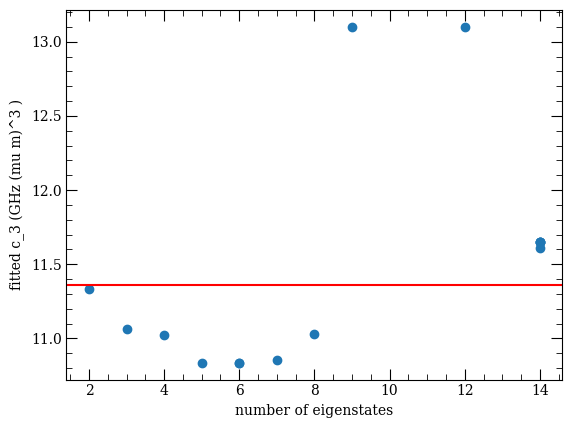

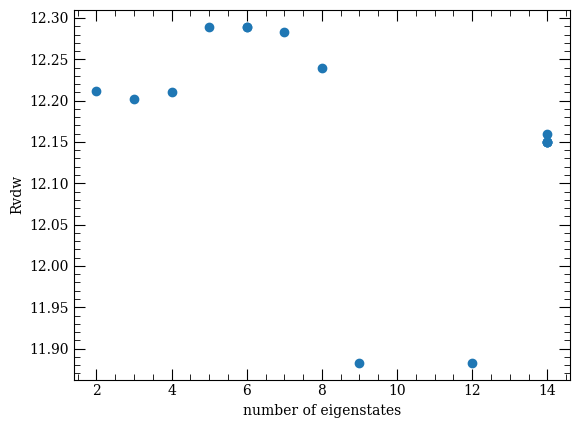

In [17]:
plt.figure()
plt.scatter(no_states, c3_fits)
plt.ylabel('fitted c_3 (GHz (mu m)^3 )')
plt.xlabel('number of eigenstates')
plt.axhline(y=c3ks[channel-1] * np.sqrt(c[8]), color='red')

plt.figure()
plt.scatter(no_states, rvdws)
plt.ylabel('Rvdw')
plt.xlabel('number of eigenstates')
# plt.axhline(y=(c3k*1e9*np.sqrt(c[8])/abs(c[7])*1e3)**(1/3), color='red')

plt.show()

In [ ]:
no_states.append(len(pair.channel))
c3_fits.append(c3)

In [ ]:
single_channel_c3s.append(abs(c3ks[channel-1] * np.sqrt(relevant_channel[channel-1][8])))
fitted_c3.append(abs(c3 - c3ks[channel-1] * relevant_channel[channel-1][8]))

In [ ]:
print(relevant_channel[channel-1][8])
print(single_channel_c3s)
print(fitted_c3)

1.5555555555555556
[np.float64(12.033814788528899), np.float64(12.737563623655864), np.float64(2.1022927307869166)]
[np.float64(3.0411597587859625), np.float64(3.750642429535354), np.float64(0.5450339730141467)]


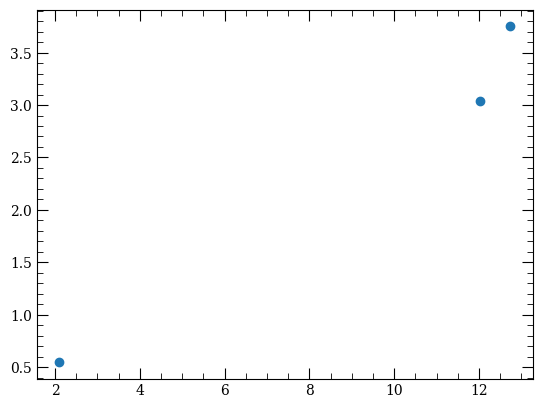

In [ ]:
plt.figure()
plt.scatter(single_channel_c3s, fitted_c3)
plt.show()

In [ ]:
print(c6)
print(c3**2/abs(c[7]))
print(c3)

c3_from_c6 = np.sqrt(c6*abs(c[7])/1e3)
print(c3_from_c6)
print(f'percentage dif = {(c3 - c3_from_c6)/c3*100}')

18784.44767027275
0.0
False
11.517396570757885
percentage dif = -inf


C:\Users\Tommy\AppData\Local\Temp\ipykernel_14564\2071872033.py:7: RuntimeWarning: divide by zero encountered in scalar divide
  print(f'percentage dif = {(c3 - c3_from_c6)/c3*100}')


7.061715419933847


c:\Users\Tommy\OneDrive - Durham University\level 4 Project\L4 code directory\.venv\Lib\site-packages\arc\calculations_atom_pairstate.py:4804: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  self.ax.scatter(


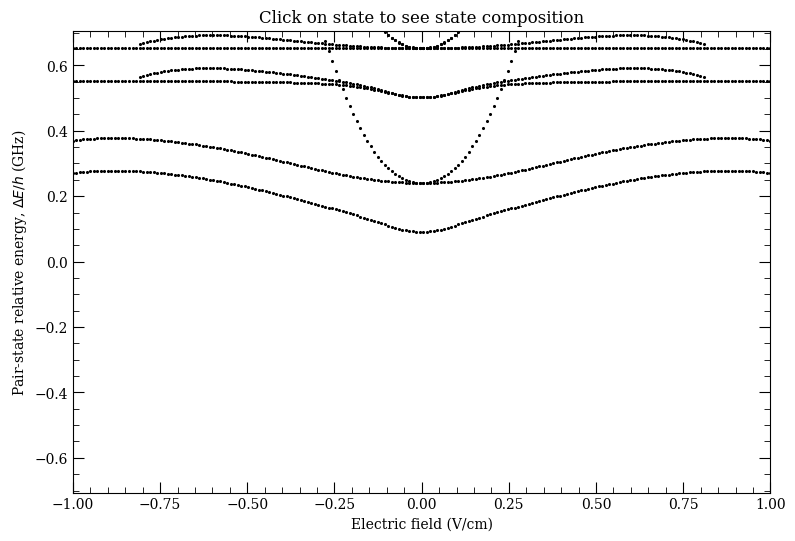

In [ ]:
efield = 100
calculation = StarkMapResonances(
    Rubidium(), [c[0], 0, 0.5, 0.5] ,Caesium(), [c[1], 0, 0.5, 0.5])

print(c[7])

calculation.findResonances(
    c[0]-3, c[0]+3, 1, np.linspace(-efield, efield, 200), energyRange=[-1*c[7]*1e8, 1*c[7]*1e8]
)



calculation.showPlot(interactive=True)

In [ ]:
single_channel_c3s = []
fitted_c3 = []